# Lab 7: Reproducing an Occupancy-Detection Study 🏢

Can measurements from ordinary environmental sensors tell us whether an office
is occupied? And does giving a model more sensors always make it better?

In this lab, you will reproduce part of a published machine-learning study:

> Luis M. Candanedo and Véronique Feldheim, “Accurate occupancy detection of
> an office room from light, temperature, humidity and CO₂ measurements using
> statistical learning models,” *Energy and Buildings* 112 (2016), 28–39.

The authors measured temperature, relative humidity, light, CO₂, and humidity
ratio about once per minute. They determined the true occupancy from
timestamped photographs. Their data are available through the
[UCI Machine Learning Repository](https://doi.org/10.24432/C5X01N), and their
[analysis code is public](https://github.com/LuisM78/Occupancy-detection-data).

You will preserve the authors' training period and two external test periods.
You will use scikit-learn pipelines, `GridSearchCV`, and three classifiers you
have already seen: logistic regression, k-nearest neighbors, and random forest.
Random forest is a direct replication of one of the paper's models; logistic
regression and kNN are extensions.

You should complete this entire lab so that all tests pass.


In [1]:
in_colab = "google.colab" in str(get_ipython())
if in_colab:
    !pip install otter-grader==6.1.6

from pathlib import Path
import json
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

path = 'labs/lab07/build/student'
if in_colab and not Path('data').exists():
    !wget -q -O /content/course.zip https://github.com/dsc-courses/cosmos-ml-cluster-2026/archive/refs/heads/main.zip
    with zipfile.ZipFile('/content/course.zip') as course_zip:
        archive_prefix = f'cosmos-ml-cluster-2026-main/{path}/'
        members = [name for name in course_zip.namelist() if name.startswith(archive_prefix)]
        course_zip.extractall('/content/course-assets', members)
    source_path = Path('/content/course-assets') / archive_prefix
    shutil.copytree(source_path / 'data', 'data', dirs_exist_ok=True)
    shutil.copytree(source_path / 'tests', 'tests', dirs_exist_ok=True)

import otter
grader = otter.Notebook()

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)


## 1. Understand the experiment 🔎

### Why detect occupancy?

Buildings use a great deal of energy heating, cooling, ventilating, and
lighting rooms. If a control system knows that a room is empty, it can turn
down those systems instead of conditioning an unused space. Occupancy
information can also help keep an occupied room comfortable, show whether a
shared room is available, or alert staff when a supposedly empty area is in
use.

Why not simply point a camera at the room? A camera can be an effective way to
detect people, but continuously sending or storing office images creates
serious privacy concerns. Images also require more storage, bandwidth, and
computation than a handful of sensor readings, and camera predictions may fail
when a person is blocked from view or the lighting is poor. The goal of this
study is therefore to learn whether small, non-visual environmental
measurements can provide a useful occupancy signal. The researchers did use a
camera to create the ground-truth labels for this experiment, but the fitted
models use no images and would not require a camera when deployed.

### How were the data collected?

Sensors in one office recorded temperature, relative humidity, light level,
and CO₂ concentration approximately once per minute. `HumidityRatio` was then
derived from temperature and relative humidity. A timestamped photograph was
taken every minute and inspected to determine whether the room was occupied at
that time.

The target is binary presence, not a count: `Occupancy = 1` means at least one
person was present, and `Occupancy = 0` means nobody was present. It does not
tell us how many people were in the office, and there is no minimum-capacity
threshold beyond the presence of a person.

People can affect several sensors. We exhale CO₂ and water vapor and give off
heat, so CO₂, humidity, and temperature may rise while a room is occupied.
People may also switch on the lights. These are useful clues, but none is a
perfect cause-and-effect rule: ventilation, an open door, outdoor weather, and
automatic lighting can change the same measurements.

### Why are there three files?

The authors provide three consecutive *measurement periods*, with small gaps
between them:

| File | Dates | Rows | Role in the paper |
| --- | --- | ---: | --- |
| `occupancy_test_closed.csv` | Feb. 2–4, 2015 | 2,665 | Earlier external test period; door mostly closed during occupancy |
| `occupancy_train.csv` | Feb. 4–10, 2015 | 8,143 | Training and cross-validation period |
| `occupancy_test_open.csv` | Feb. 11–18, 2015 | 9,752 | Later external test period; door mostly open during occupancy |

“Middle period” means the middle file in chronological order, not the middle
third of one shuffled dataset. We use it for training because that is the
protocol chosen before evaluation in the original paper. Keeping the same
partition makes our results comparable with the authors' results and prevents
us from choosing a training period after seeing which choice scores best. The
two external files then test whether a model transfers backward to an earlier
similar period and forward to a later period with a changed door condition.
The middle file is not inherently the only valid training choice; a new study
could compare other chronological protocols, but that would be a different
experiment.

The target `Occupancy` is 1 when the room was occupied and 0 otherwise. The
sensor columns are:

| Column | Meaning | Unit |
| --- | --- | --- |
| `Temperature` | Air temperature | °C |
| `Humidity` | Relative humidity | % |
| `Light` | Illuminance | Lux |
| `CO2` | Carbon dioxide concentration | ppm |
| `HumidityRatio` | Water vapor divided by dry air | kg/kg |


In [2]:
training = pd.read_csv('data/occupancy_train.csv')

sensor_columns = [
    'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio'
]
X_train = training[['date', *sensor_columns]]
y_train = training['Occupancy']

training.head()


,id,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
1,2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
2,3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
3,4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
4,5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


**Question 1.1.** Audit the training period. Assign:

- `training_shape` to the shape of `training`.
- `training_start` to its earliest timestamp as a pandas `Timestamp`.
- `training_end` to its latest timestamp as a pandas `Timestamp`.
- `num_missing` to the total number of missing values in the DataFrame.
- `num_duplicate_ids` to the number of duplicated values in the `id` column.


In [3]:
# BEGIN SOLUTION
training_shape = training.shape
training_times = pd.to_datetime(training['date'])
training_start = training_times.min()
training_end = training_times.max()
num_missing = training.isna().sum().sum()
num_duplicate_ids = training['id'].duplicated().sum()
# END SOLUTION

print(f'Rows and columns: {training_shape}')
print(f'Training period: {training_start} through {training_end}')
print(f'Missing values: {num_missing}')
print(f'Duplicate IDs: {num_duplicate_ids}')


Rows and columns: (8143, 8)
Training period: 2015-02-04 17:51:00 through 2015-02-10 09:33:00
Missing values: 0
Duplicate IDs: 0


In [4]:
bool(training_shape == (8143, 8))

True

In [5]:
bool(training_start == pd.Timestamp('2015-02-04 17:51:00'))

True

In [6]:
bool(training_end == pd.Timestamp('2015-02-10 09:33:00'))

True

In [7]:
bool(num_missing == 0 and num_duplicate_ids == 0)

True

**Question 1.2.** Store the proportion of training rows in each class in
`occupancy_rates`, indexed by 0 and 1 in that order. Then store the accuracy
of a classifier that always predicts the most common class in
`majority_baseline`.

This deliberately simple classifier is a **baseline**. It tells us how much
accuracy is available without looking at a single sensor. A useful fitted
model should do at least as well as this baseline; otherwise we would be
better off always making the most common prediction.


In [8]:
# BEGIN SOLUTION
occupancy_rates = y_train.value_counts(normalize=True).sort_index()
majority_baseline = occupancy_rates.max()
# END SOLUTION

display(occupancy_rates.rename('proportion'))
print(f'Majority-class baseline accuracy: {majority_baseline:.1%}')


Occupancy
0    0.78767
1    0.21233
Name: proportion, dtype: float64

Majority-class baseline accuracy: 78.8%


In [9]:
bool(list(occupancy_rates.index) == [0, 1])

True

In [10]:
bool(np.isclose(occupancy_rates.sum(), 1))

True

In [11]:
bool(np.isclose(occupancy_rates.loc[1], 0.2123296082524868))

True

In [12]:
bool(np.isclose(majority_baseline, occupancy_rates.loc[0]))

True

### Sensor measurements over time

Run the cell below to reproduce the paper's basic time-series exploration. The
gray shading marks times when the office was occupied. Plotting every point is
useful here because the order of the measurements matters.


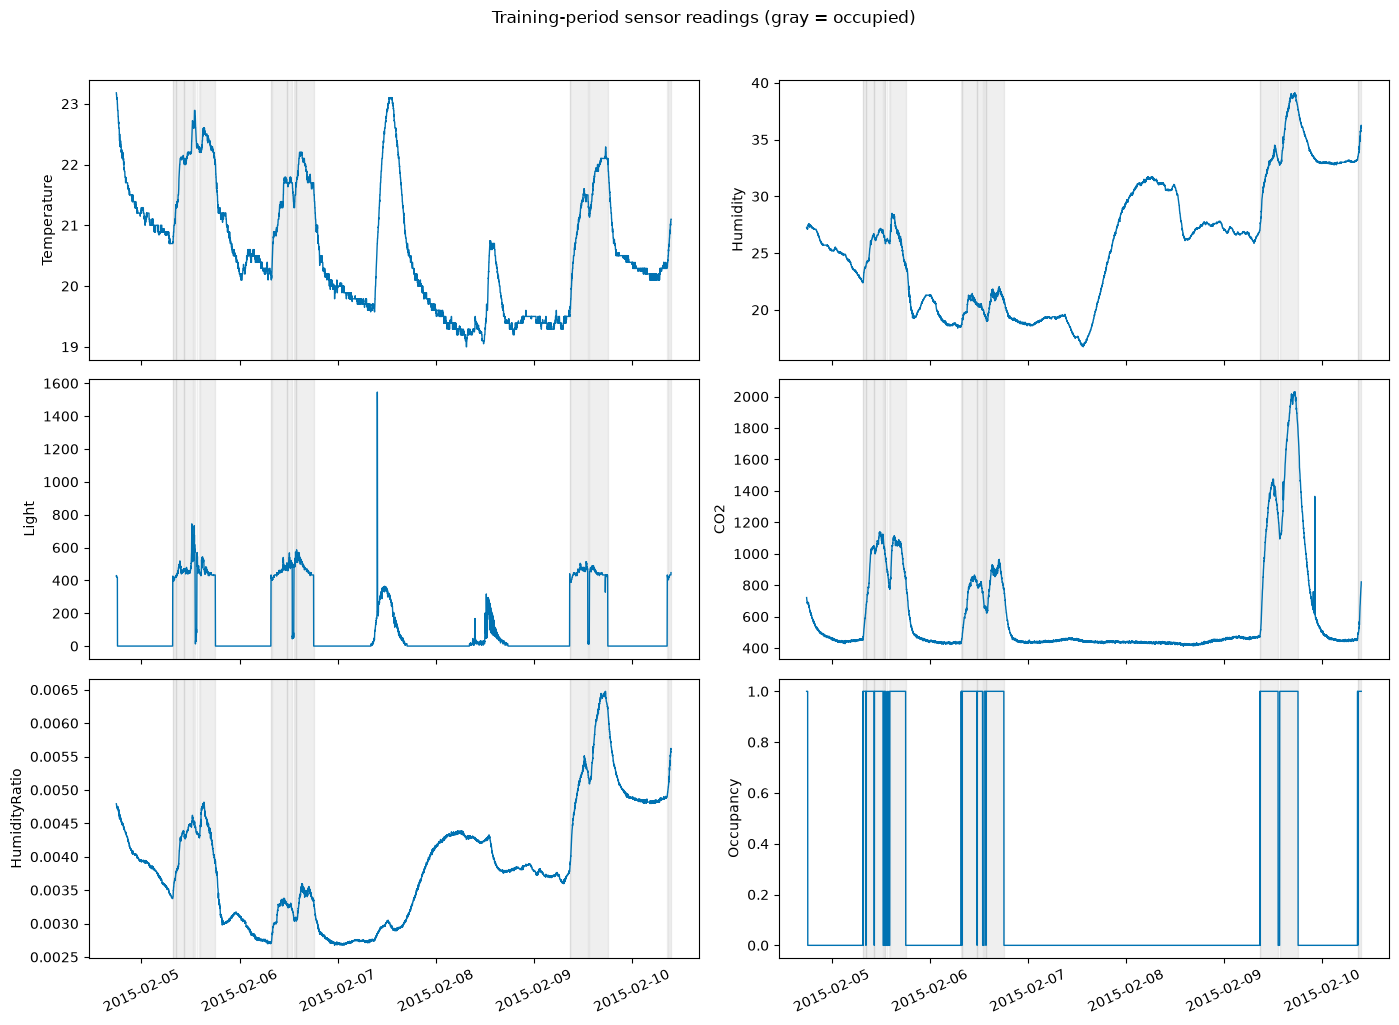

In [13]:
plot_data = training.copy()
plot_data['date'] = pd.to_datetime(plot_data['date'])

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
plot_columns = [*sensor_columns, 'Occupancy']

for axis, column in zip(axes.flat, plot_columns):
    axis.plot(plot_data['date'], plot_data[column], linewidth=1)
    axis.set_ylabel(column)
    for start in plot_data.loc[plot_data['Occupancy'].diff().eq(1), 'date']:
        later = plot_data.loc[
            (plot_data['date'] >= start) & plot_data['Occupancy'].eq(0), 'date'
        ]
        end = later.iloc[0] if len(later) else plot_data['date'].iloc[-1]
        axis.axvspan(start, end, color='gray', alpha=0.12)

axes[-1, 0].tick_params(axis='x', rotation=25)
axes[-1, 1].tick_params(axis='x', rotation=25)
fig.suptitle('Training-period sensor readings (gray = occupied)', y=1.02)
fig.tight_layout()


**Pause and interpret.** Which sensor most visibly separates occupied from
unoccupied periods? Which measurements seem to respond slowly after somebody
enters or leaves? Why might `HumidityRatio` contain less new information than
its name suggests?


## 2. Recreate the paper's feature engineering 🕒

The authors did not pass the raw timestamp into their models. They extracted
the number of seconds since midnight (`NSM`) and whether the date was a weekday
or weekend (`WeekStatus`). We will recreate those two features.

Crucially, the operation belongs inside the model pipeline. Every candidate
model will then receive exactly the feature recipe it is supposed to use.


**Question 2.1.** Complete `make_occupancy_features`. It should:

1. Return a copy containing only the requested `sensor_columns`.
2. If `include_time` is true, add `seconds_since_midnight` and
   `is_weekend`.
3. Never include `id`, the raw `date`, or `Occupancy`.

`seconds_since_midnight` should be 0 at midnight and 43,200 at noon.
`is_weekend` should be 1 on Saturday or Sunday and 0 otherwise.


In [14]:
# BEGIN SOLUTION
def make_occupancy_features(data, sensor_columns, include_time):
    '''Select sensors and optionally derive numerical timestamp features.'''
    result = data[list(sensor_columns)].copy()

    if include_time:
        timestamp = pd.to_datetime(data['date'])
        result['seconds_since_midnight'] = (
            timestamp.dt.hour * 3600
            + timestamp.dt.minute * 60
            + timestamp.dt.second
        )
        result['is_weekend'] = (timestamp.dt.dayofweek >= 5).astype(int)

    return result
# END SOLUTION

make_occupancy_features(X_train.head(), sensor_columns, include_time=True)


,Temperature,Humidity,Light,CO2,HumidityRatio,seconds_since_midnight,is_weekend
0,23.18,27.2720,426.0,721.25,0.004793,64260,0
1,23.15,27.2675,429.5,714.00,0.004783,64319,0
2,23.15,27.2450,426.0,713.50,0.004779,64380,0
3,23.15,27.2000,426.0,708.25,0.004772,64440,0
4,23.10,27.2000,426.0,704.50,0.004757,64500,0


In [15]:
bool(list(make_occupancy_features(X_train.head(), ['Light'], False).columns) == ['Light'])

True

In [16]:
bool(list(make_occupancy_features(X_train.head(), ['Light'], True).columns) == ['Light', 'seconds_since_midnight', 'is_weekend'])

True

In [17]:
bool(make_occupancy_features(pd.DataFrame({'date': ['2015-02-07 00:00:00', '2015-02-09 12:00:00'], 'Light': [0, 1]}), ['Light'], True)['seconds_since_midnight'].tolist() == [0, 43200])

True

In [18]:
bool(make_occupancy_features(pd.DataFrame({'date': ['2015-02-07 00:00:00', '2015-02-09 12:00:00'], 'Light': [0, 1]}), ['Light'], True)['is_weekend'].tolist() == [1, 0])

True

**Question 2.2.** Create `time_transformer`, a `FunctionTransformer` that
calls `make_occupancy_features` with all five sensors and time features.
Store its transformed first three training rows in `transformed_example`.


In [19]:
# BEGIN SOLUTION
time_transformer = FunctionTransformer(
    make_occupancy_features,
    kw_args={
        'sensor_columns': sensor_columns,
        'include_time': True,
    },
)
transformed_example = time_transformer.transform(X_train.head(3))
# END SOLUTION

transformed_example

,Temperature,Humidity,Light,CO2,HumidityRatio,seconds_since_midnight,is_weekend
0,23.18,27.2720,426.0,721.25,0.004793,64260,0
1,23.15,27.2675,429.5,714.00,0.004783,64319,0
2,23.15,27.2450,426.0,713.50,0.004779,64380,0


In [20]:
bool(isinstance(time_transformer, FunctionTransformer))

True

In [21]:
bool(transformed_example.shape == (3, 7))

True

In [22]:
bool(list(transformed_example.columns[-2:]) == ['seconds_since_midnight', 'is_weekend'])

True

In [23]:
bool(np.isclose(transformed_example.iloc[0]['seconds_since_midnight'], 64260))

True

### Feature recipes

The paper compares all sensors, sensors plus time, models with important
sensors removed, single-sensor models, and several two-sensor combinations.
This asks a practical scientific question: **which measurements are actually
needed?** Sensors cost money to purchase, install, calibrate, and power. Some
features may also be redundant or noisy—for example, humidity ratio is derived
from two other measurements—so giving a model every available column need not
improve its predictions.

Time is another deliberate modeling choice. Seconds since midnight and
weekday/weekend status can capture a regular office schedule, which may improve
accuracy even when sensor readings are ambiguous. But a model that relies on
the schedule may fail during holidays, unusual work hours, or in a different
office. Comparing recipes with and without time lets us measure that tradeoff
instead of assuming that time must help.

The planned recipes are stored in `feature_recipes.csv`. A CSV cannot store a
Python list directly, so its `sensor_columns` entries use JSON list notation,
such as `["Temperature", "Light"]`.


**Question 2.3.** Load `data/feature_recipes.csv` into a DataFrame named
`feature_recipes_df`. Convert every value in its `sensor_columns` column
from JSON text into a Python list of strings using `json.loads`.

Then create `feature_recipes`, a dictionary keyed by recipe name. Each
value should be a dictionary with the keys `'sensor_columns'` and
`'include_time'`, ready to pass directly to `make_occupancy_features`.

*Hint:* after parsing the lists, `.set_index('recipe').to_dict(orient='index')`
performs the final conversion.


In [24]:
# BEGIN SOLUTION
feature_recipes_df = pd.read_csv('data/feature_recipes.csv')
feature_recipes_df['sensor_columns'] = (
    feature_recipes_df['sensor_columns'].apply(json.loads)
)
feature_recipes = (
    feature_recipes_df
    .set_index('recipe')
    .to_dict(orient='index')
)
# END SOLUTION

feature_recipes_df

,recipe,sensor_columns,include_time
0,all_sensors,"[Temperature, Humidity, Light, CO2, HumidityRatio]",False
1,all_plus_time,"[Temperature, Humidity, Light, CO2, HumidityRatio]",True
2,no_light_time,"[Temperature, Humidity, CO2, HumidityRatio]",True
3,no_co2_time,"[Temperature, Humidity, Light, HumidityRatio]",True
4,light_only,[Light],False
5,light_time,[Light],True
6,temperature_only,[Temperature],False
7,temperature_time,[Temperature],True
8,temperature_light_time,"[Temperature, Light]",True
9,humidity_light_time,"[Humidity, Light]",True


In [25]:
bool(feature_recipes_df.shape == (12, 3))

True

In [26]:
bool(feature_recipes_df['sensor_columns'].map(lambda value: isinstance(value, list) and all(isinstance(column, str) for column in value)).all())

True

In [27]:
bool(len(feature_recipes) == 12)

True

In [28]:
bool(set(feature_recipes['all_sensors']['sensor_columns']) == set(sensor_columns) and not feature_recipes['all_sensors']['include_time'])

True

In [29]:
bool('Light' not in feature_recipes['no_light_time']['sensor_columns'] and feature_recipes['no_light_time']['include_time'])

True

## 3. Tune three classifiers ⚙️

Accuracy is the paper's main metric, so it will also be the score optimized by
our searches. Because the occupied class is less common, we will use
`StratifiedKFold` so every fold has a similar class balance.

Every pipeline will use this order:

1. Select and engineer features with `FunctionTransformer`.
2. Standardize them with `StandardScaler`.
3. Fit the classifier.

Scaling is important for logistic regression and kNN. A random forest does not
need it, but using the same preprocessing structure makes the comparison
consistent.


**Question 3.1.** Create `folds`, a five-fold `StratifiedKFold` that shuffles
with `random_state=0`. Then complete `model_specs` for all three classifiers.

`model_specs` is a dictionary whose keys are the model names. Each model's
value is another dictionary with exactly two entries:

- `'estimator'` must contain an **unfitted scikit-learn classifier object**,
  such as `LogisticRegression(...)`. It is not a string, a classifier class, or
  an already-fitted model.
- `'parameter_grid'` must contain a **dictionary** mapping pipeline parameter
  names to lists of candidate values. Because the classifier lives inside a
  pipeline, each parameter name begins with the automatically generated step
  name, followed by two underscores—for example,
  `'logisticregression__C'`.

The logistic-regression entry is completed as an example. Add:

- `knn`: an unfitted `KNeighborsClassifier` with `n_jobs=-1`; search 3, 5, 11,
  25, or 51 neighbors and `'uniform'` or `'distance'` weights.
- `random_forest`: an unfitted `RandomForestClassifier` with 200 trees,
  `random_state=0`, and `n_jobs=1`; search maximum depth `None` or 8, minimum
  leaf size 1 or 5, and maximum features `'sqrt'` or `None`.


In [30]:
# BEGIN SOLUTION
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
# END SOLUTION


In [31]:
model_specs = {
    # This completed entry shows the required structure.
    'logistic_regression': {
        'estimator': LogisticRegression(max_iter=2000, random_state=0),
        'parameter_grid': {
            'logisticregression__C': [0.01, 0.1, 1, 10],
        },
    },
    # BEGIN SOLUTION
    'knn': {
        'estimator': KNeighborsClassifier(n_jobs=-1),
        'parameter_grid': {
            'kneighborsclassifier__n_neighbors': [3, 5, 11, 25, 51],
            'kneighborsclassifier__weights': ['uniform', 'distance'],
        },
    },
    'random_forest': {
        'estimator': RandomForestClassifier(
            n_estimators=200,
            random_state=0,
            n_jobs=1,
        ),
        'parameter_grid': {
            'randomforestclassifier__max_depth': [None, 8],
            'randomforestclassifier__min_samples_leaf': [1, 5],
            'randomforestclassifier__max_features': ['sqrt', None],
        },
    },
    # END SOLUTION
}


In [32]:
bool(isinstance(folds, StratifiedKFold) and folds.n_splits == 5 and folds.shuffle and folds.random_state == 0)

True

In [33]:
bool(set(model_specs) == {'logistic_regression', 'knn', 'random_forest'})

True

In [34]:
bool(isinstance(model_specs['logistic_regression']['estimator'], LogisticRegression) and isinstance(model_specs['logistic_regression']['parameter_grid'], dict))

True

In [35]:
bool(model_specs['logistic_regression']['parameter_grid']['logisticregression__C'] == [0.01, 0.1, 1, 10])

True

In [36]:
bool(model_specs['random_forest']['estimator'].n_estimators == 200 and model_specs['random_forest']['estimator'].random_state == 0)

True

**Question 3.2.** Complete `make_search`. It should create and return an
unfitted `GridSearchCV` containing a pipeline with a `FunctionTransformer`,
`StandardScaler`, and a clone of the supplied estimator.

Configure the search with `folds`, accuracy scoring, `n_jobs=-1`, and
`return_train_score=True`.


In [37]:
# BEGIN SOLUTION
def make_search(estimator, parameter_grid, recipe):
    '''Create an unfitted grid search for one model and feature recipe.'''
    feature_transformer = FunctionTransformer(
        make_occupancy_features,
        kw_args=recipe,
    )
    pipeline = make_pipeline(
        feature_transformer,
        StandardScaler(),
        clone(estimator),
    )
    return GridSearchCV(
        pipeline,
        parameter_grid,
        cv=folds,
        scoring='accuracy',
        n_jobs=-1,
        return_train_score=True,
    )
# END SOLUTION


In [38]:
bool(isinstance(make_search(model_specs['knn']['estimator'], model_specs['knn']['parameter_grid'], feature_recipes['all_plus_time']), GridSearchCV))

True

In [39]:
bool(list(make_search(model_specs['knn']['estimator'], model_specs['knn']['parameter_grid'], feature_recipes['all_plus_time']).estimator.named_steps) == ['functiontransformer', 'standardscaler', 'kneighborsclassifier'])

True

In [40]:
bool(make_search(model_specs['knn']['estimator'], model_specs['knn']['parameter_grid'], feature_recipes['all_plus_time']).scoring == 'accuracy')

True

In [41]:
bool(make_search(model_specs['knn']['estimator'], model_specs['knn']['parameter_grid'], feature_recipes['all_plus_time']).return_train_score)

True

### Establish a common baseline

First, tune all three classifiers using all five sensors plus the two timestamp
features. The test periods are still untouched.


**Question 3.3.** For every item in `model_specs`, create a search using the
`all_plus_time` recipe and fit it on `X_train` and `y_train`.

Store the fitted searches in `baseline_searches`, keyed by model name.
Create `baseline_results`, a DataFrame with one row per model and these
columns: `'model'`, `'cv_accuracy'`, `'cv_std'`, `'train_accuracy'`, and
`'best_parameters'`.


In [42]:
# BEGIN SOLUTION
baseline_searches = {}
baseline_rows = []

for model_name, specification in model_specs.items():
    search = make_search(
        specification['estimator'],
        specification['parameter_grid'],
        feature_recipes['all_plus_time'],
    )
    search.fit(X_train, y_train)
    baseline_searches[model_name] = search

    best_index = search.best_index_
    baseline_rows.append({
        'model': model_name,
        'cv_accuracy': search.best_score_,
        'cv_std': search.cv_results_['std_test_score'][best_index],
        'train_accuracy': search.cv_results_['mean_train_score'][best_index],
        'best_parameters': search.best_params_,
    })

baseline_results = pd.DataFrame(baseline_rows)
# END SOLUTION

baseline_results.sort_values('cv_accuracy', ascending=False)

,model,cv_accuracy,cv_std,train_accuracy,best_parameters
2,random_forest,0.994474,0.001345,1.000000,"{'randomforestclassifier__max_depth': None, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier_..."
1,knn,0.993737,0.001957,1.000000,"{'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__weights': 'distance'}"
0,logistic_regression,0.988457,0.002889,0.988456,{'logisticregression__C': 0.1}


In [43]:
bool(set(baseline_searches) == set(model_specs))

True

In [44]:
bool(all(isinstance(search, GridSearchCV) for search in baseline_searches.values()))

True

In [45]:
bool(list(baseline_results.columns) == ['model', 'cv_accuracy', 'cv_std', 'train_accuracy', 'best_parameters'])

True

In [46]:
bool(len(baseline_results) == 3 and baseline_results['cv_accuracy'].between(0.95, 1).all())

True

**Pause and interpret.** Which model has the highest cross-validation accuracy?
Are the gaps large enough to matter? Which model has the largest gap between
training and CV accuracy? Why have we still not loaded either test file?


## 4. Reproduce the feature-selection study 🧪

A scientific replication is a planned set of comparisons, not an unlimited
search for whichever number looks best. We fixed our 12 feature recipes and
three hyperparameter grids before examining either external test period.

The next search fits 36 model/feature combinations. It may take a minute or two
in Colab. The `all_plus_time` searches have already been fit, so reuse them.


**Question 4.1.** Fit a grid search for every feature recipe and model.
Store each fitted search in `searches`, using `(recipe_name, model_name)` as
its key. Reuse the corresponding object from `baseline_searches` for the
`all_plus_time` recipe.

Create `cv_results` with the columns `'recipe'`, `'model'`,
`'num_features'`, `'cv_accuracy'`, `'cv_std'`, `'train_accuracy'`, and
`'best_parameters'`. Count the output columns of the fitted feature
transformer when computing `num_features`.


In [47]:
# BEGIN SOLUTION
searches = {}
cv_rows = []

for recipe_name, recipe in feature_recipes.items():
    for model_name, specification in model_specs.items():
        if recipe_name == 'all_plus_time':
            search = baseline_searches[model_name]
        else:
            search = make_search(
                specification['estimator'],
                specification['parameter_grid'],
                recipe,
            )
            search.fit(X_train, y_train)

        searches[(recipe_name, model_name)] = search
        best_index = search.best_index_
        transformed = search.best_estimator_.named_steps[
            'functiontransformer'
        ].transform(X_train.head(1))

        cv_rows.append({
            'recipe': recipe_name,
            'model': model_name,
            'num_features': transformed.shape[1],
            'cv_accuracy': search.best_score_,
            'cv_std': search.cv_results_['std_test_score'][best_index],
            'train_accuracy': search.cv_results_['mean_train_score'][best_index],
            'best_parameters': search.best_params_,
        })

cv_results = pd.DataFrame(cv_rows)
# END SOLUTION

cv_results.pivot(index='recipe', columns='model', values='cv_accuracy').style.format('{:.2%}')


model,knn,logistic_regression,random_forest
recipe,,,
all_plus_time,99.37%,98.85%,99.45%
all_sensors,99.35%,98.77%,99.36%
co2_light_time,99.29%,98.87%,99.47%
humidity_light_time,99.34%,98.86%,99.44%
light_only,98.77%,98.51%,98.75%
light_time,99.08%,98.86%,99.16%
no_co2_time,99.37%,98.85%,99.47%
no_light_time,99.18%,94.09%,99.32%
temperature_humidity_time,99.18%,88.49%,99.34%


In [48]:
bool(len(searches) == len(feature_recipes) * len(model_specs) == 36)

True

In [49]:
bool(list(cv_results.columns) == ['recipe', 'model', 'num_features', 'cv_accuracy', 'cv_std', 'train_accuracy', 'best_parameters'])

True

In [50]:
bool(len(cv_results) == 36 and not cv_results.duplicated(['recipe', 'model']).any())

True

In [51]:
bool(cv_results['cv_accuracy'].between(majority_baseline, 1).all())

True

### Freeze the choices

For each classifier, we will select the feature recipe with the highest CV
accuracy. Once these choices are recorded, we will not refit or retune anything
after seeing external test results.


**Question 4.2.** Create `frozen_choices`, containing the row of
`cv_results` with the highest `cv_accuracy` for each model. Sort it by model
name and reset its index. Then create `frozen_searches`, mapping each model
name to its already-fitted selected search.


In [52]:
# BEGIN SOLUTION
frozen_indices = cv_results.groupby('model')['cv_accuracy'].idxmax()
frozen_choices = (
    cv_results.loc[frozen_indices]
    .sort_values('model')
    .reset_index(drop=True)
)

frozen_searches = {
    row['model']: searches[(row['recipe'], row['model'])]
    for _, row in frozen_choices.iterrows()
}
# END SOLUTION

frozen_choices[['model', 'recipe', 'num_features', 'cv_accuracy', 'best_parameters']]

,model,recipe,num_features,cv_accuracy,best_parameters
0,knn,all_plus_time,7,0.993737,"{'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__weights': 'distance'}"
1,logistic_regression,co2_light_time,4,0.988702,{'logisticregression__C': 1}
2,random_forest,no_co2_time,6,0.994719,"{'randomforestclassifier__max_depth': 8, 'randomforestclassifier__max_features': None, 'randomforestclassifier__min_..."


In [53]:
bool(len(frozen_choices) == 3 and set(frozen_choices['model']) == set(model_specs))

True

In [54]:
bool(set(frozen_searches) == set(model_specs))

True

In [55]:
bool(all(search is searches[(frozen_choices.set_index('model').loc[name, 'recipe'], name)] for name, search in frozen_searches.items()))

True

In [56]:
bool(np.allclose(frozen_choices.set_index('model')['cv_accuracy'].sort_index(), cv_results.groupby('model')['cv_accuracy'].max().sort_index()))

True

Before continuing, write down a prediction: which frozen model will transfer
best to the two external periods? Will the winner be the same for both?


**Question 4.3.** A fitted random forest records a **feature importance**
for every input column. In scikit-learn, this measures how much the trees'
splits using that feature reduced impurity, averaged across the forest. The
values are nonnegative and sum to 1, so a larger value means the forest
relied more heavily on that feature when making its splits.

The classifier is nested inside the selected pipeline. Retrieve the fitted
pipeline with:

```python
frozen_forest = frozen_searches['random_forest'].best_estimator_
```

Then retrieve the fitted classifier and its importance array with:

```python
forest_classifier = frozen_forest.named_steps['randomforestclassifier']
forest_classifier.feature_importances_
```

The array is in the same order as the columns produced by the pipeline's
`functiontransformer`. Store the importances in `forest_importances`, a
descending Series indexed by those transformed feature names. Then make a
horizontal bar chart.

Feature importance does not give the direction of a relationship, prove
causation, or fairly divide credit between strongly correlated features.


Light                     0.943964
seconds_since_midnight    0.028335
Temperature               0.010321
Humidity                  0.009696
HumidityRatio             0.004714
is_weekend                0.002969
Name: importance, dtype: float64

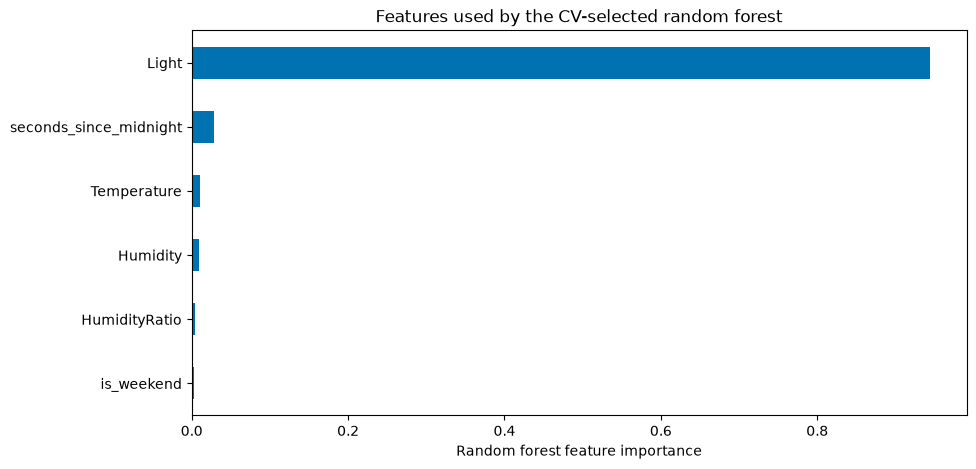

In [57]:
# BEGIN SOLUTION
frozen_forest = frozen_searches['random_forest'].best_estimator_
forest_transformer = frozen_forest.named_steps['functiontransformer']
forest_feature_names = forest_transformer.transform(X_train.head(1)).columns
forest_classifier = frozen_forest.named_steps['randomforestclassifier']

forest_importances = pd.Series(
    forest_classifier.feature_importances_,
    index=forest_feature_names,
    name='importance',
).sort_values(ascending=False)

forest_importances.sort_values().plot.barh()
plt.xlabel('Random forest feature importance')
plt.title('Features used by the CV-selected random forest')
# END SOLUTION

forest_importances

In [58]:
bool(isinstance(forest_importances, pd.Series))

True

In [59]:
bool(np.isclose(forest_importances.sum(), 1))

True

In [60]:
bool(forest_importances.is_monotonic_decreasing)

True

In [61]:
bool(set(forest_importances.index) == set(forest_feature_names))

True

**Pause and interpret.** Is light important to the selected forest? Does feature
importance prove that a sensor causes occupancy? Why should the importance of
`HumidityRatio` be interpreted cautiously?


## 5. Evaluate on two external periods 🚪

Every modeling choice is now frozen. We can finally load the two test periods.
The first was measured under conditions similar to training, with the office
door mostly closed during occupancy. In the second, the door was mostly open.
An open door can change how temperature, humidity, and CO₂ behave.

Notice also that the first test period occurs *before* the training period,
while the second occurs after it. This is transfer across measurement periods,
not a random held-out sample.


In [62]:
test_closed = pd.read_csv('data/occupancy_test_closed.csv')
test_open = pd.read_csv('data/occupancy_test_open.csv')

X_test_closed = test_closed[['date', *sensor_columns]]
y_test_closed = test_closed['Occupancy']
X_test_open = test_open[['date', *sensor_columns]]
y_test_open = test_open['Occupancy']

test_summary = pd.DataFrame({
    'rows': [len(test_closed), len(test_open)],
    'start': [pd.to_datetime(test_closed['date']).min(), pd.to_datetime(test_open['date']).min()],
    'end': [pd.to_datetime(test_closed['date']).max(), pd.to_datetime(test_open['date']).max()],
    'occupied_rate': [y_test_closed.mean(), y_test_open.mean()],
}, index=['closed-door period', 'open-door period'])
test_summary


,rows,start,end,occupied_rate
closed-door period,2665,2015-02-02 14:19:00,2015-02-04 10:43:00,0.364728
open-door period,9752,2015-02-11 14:48:00,2015-02-18 09:19:00,0.210111


**Question 5.1.** Evaluate each frozen search on both external periods.
Create `frozen_test_results` with these columns:

- `'model'` and `'recipe'`
- `'cv_accuracy'`
- `'closed_accuracy'` and `'open_accuracy'`

Do not call `.fit` anywhere in this question.


In [63]:
# BEGIN SOLUTION
frozen_test_rows = []

for _, choice in frozen_choices.iterrows():
    model_name = choice['model']
    search = frozen_searches[model_name]

    frozen_test_rows.append({
        'model': model_name,
        'recipe': choice['recipe'],
        'cv_accuracy': choice['cv_accuracy'],
        'closed_accuracy': search.score(X_test_closed, y_test_closed),
        'open_accuracy': search.score(X_test_open, y_test_open),
    })

frozen_test_results = pd.DataFrame(frozen_test_rows)
# END SOLUTION

frozen_test_results.style.format({column: '{:.2%}' for column in frozen_test_results.columns if 'accuracy' in column})

,model,recipe,cv_accuracy,closed_accuracy,open_accuracy
0,knn,all_plus_time,99.37%,93.85%,94.84%
1,logistic_regression,co2_light_time,98.87%,97.82%,99.05%
2,random_forest,no_co2_time,99.47%,95.91%,97.88%


In [64]:
bool(list(frozen_test_results.columns) == ['model', 'recipe', 'cv_accuracy', 'closed_accuracy', 'open_accuracy'])

True

In [65]:
bool(len(frozen_test_results) == 3 and set(frozen_test_results['model']) == set(model_specs))

True

In [66]:
bool(frozen_test_results[['closed_accuracy', 'open_accuracy']].apply(lambda column: column.between(0.8, 1).all()).all())

True

### A paper-style comparison table

The paper reports many already-planned model and feature combinations on both
test periods. We will do the same. This table is for replication analysis; it
does not give us permission to select a new “final” model and call its test
accuracy unbiased.


**Question 5.2.** Evaluate every fitted search in `searches` on both test
periods. Create `external_results` with the columns `'recipe'`, `'model'`,
`'cv_accuracy'`, `'closed_accuracy'`, `'open_accuracy'`, and
`'mean_external_accuracy'`.

Do not fit or tune any models. Sort the finished table from largest to
smallest `mean_external_accuracy` and reset its index.


In [67]:
# BEGIN SOLUTION
external_rows = []

cv_lookup = cv_results.set_index(['recipe', 'model'])['cv_accuracy']
for (recipe_name, model_name), search in searches.items():
    closed_accuracy = search.score(X_test_closed, y_test_closed)
    open_accuracy = search.score(X_test_open, y_test_open)
    external_rows.append({
        'recipe': recipe_name,
        'model': model_name,
        'cv_accuracy': cv_lookup.loc[(recipe_name, model_name)],
        'closed_accuracy': closed_accuracy,
        'open_accuracy': open_accuracy,
        'mean_external_accuracy': (closed_accuracy + open_accuracy) / 2,
    })

external_results = (
    pd.DataFrame(external_rows)
    .sort_values('mean_external_accuracy', ascending=False)
    .reset_index(drop=True)
)
# END SOLUTION

external_results.head(12).style.format({column: '{:.2%}' for column in ['cv_accuracy', 'closed_accuracy', 'open_accuracy', 'mean_external_accuracy']})

,recipe,model,cv_accuracy,closed_accuracy,open_accuracy,mean_external_accuracy
0,temperature_light_time,logistic_regression,98.85%,97.90%,99.46%,98.68%
1,humidity_light_time,logistic_regression,98.86%,97.90%,99.44%,98.67%
2,light_only,knn,98.77%,97.86%,99.34%,98.60%
3,all_plus_time,logistic_regression,98.85%,97.82%,99.37%,98.60%
4,light_time,logistic_regression,98.86%,97.90%,99.29%,98.60%
5,all_sensors,logistic_regression,98.77%,97.82%,99.29%,98.56%
6,light_only,logistic_regression,98.51%,97.86%,99.23%,98.55%
7,co2_light_time,logistic_regression,98.87%,97.82%,99.05%,98.43%
8,no_co2_time,logistic_regression,98.85%,97.82%,98.29%,98.06%
9,light_only,random_forest,98.75%,96.51%,98.84%,97.68%


In [68]:
bool(len(external_results) == 36 and not external_results.duplicated(['recipe', 'model']).any())

True

In [69]:
bool(list(external_results.columns) == ['recipe', 'model', 'cv_accuracy', 'closed_accuracy', 'open_accuracy', 'mean_external_accuracy'])

True

In [70]:
bool(external_results['mean_external_accuracy'].is_monotonic_decreasing)

True

In [71]:
bool(np.allclose(external_results['mean_external_accuracy'], external_results[['closed_accuracy', 'open_accuracy']].mean(axis=1)))

True

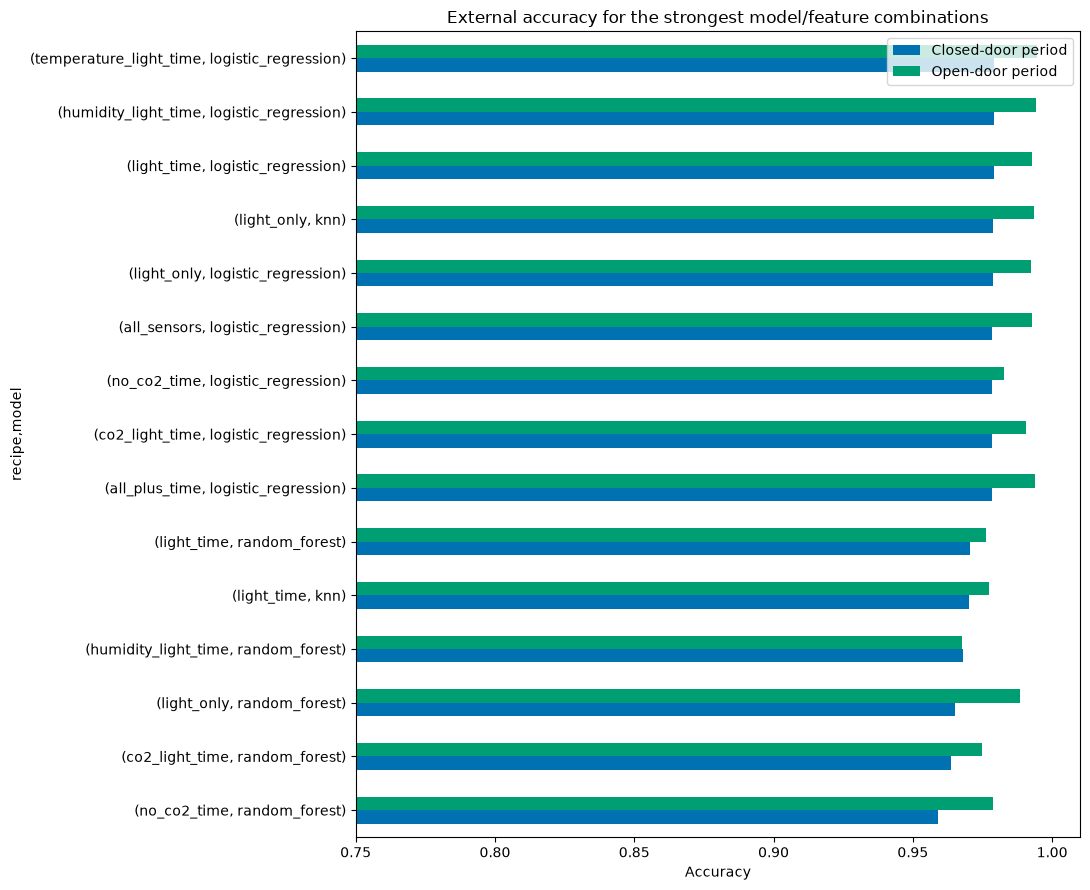

In [72]:
accuracy_plot = (
    external_results
    .set_index(['recipe', 'model'])[['closed_accuracy', 'open_accuracy']]
    .sort_values('closed_accuracy')
)
accuracy_plot.tail(15).plot.barh(figsize=(11, 9))
plt.xlabel('Accuracy')
plt.xlim(0.75, 1.01)
plt.title('External accuracy for the strongest model/feature combinations')
plt.legend(['Closed-door period', 'Open-door period'])
plt.tight_layout()


### Inspect the mistakes of the CV winner

The next cell chooses the classifier with the highest *training-period CV
accuracy*, not the one with the best test accuracy, and displays its confusion
matrices.


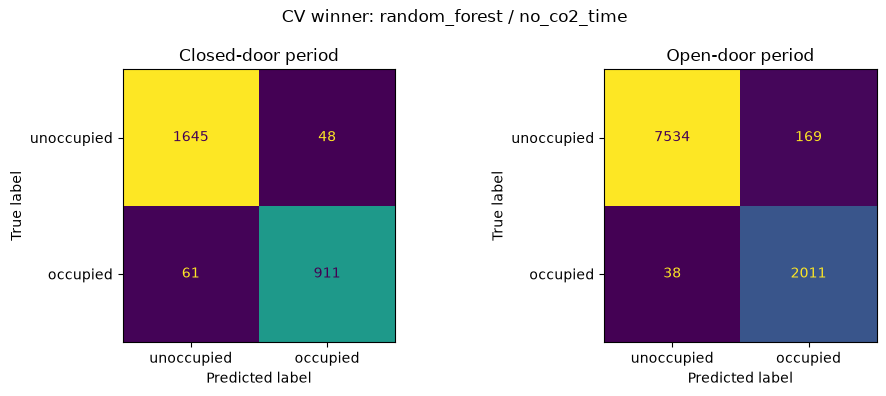

In [73]:
cv_winner_row = frozen_choices.loc[frozen_choices['cv_accuracy'].idxmax()]
cv_winner = frozen_searches[cv_winner_row['model']]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_closed,
    cv_winner.predict(X_test_closed),
    display_labels=['unoccupied', 'occupied'],
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title('Closed-door period')

ConfusionMatrixDisplay.from_predictions(
    y_test_open,
    cv_winner.predict(X_test_open),
    display_labels=['unoccupied', 'occupied'],
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title('Open-door period')
fig.suptitle(f"CV winner: {cv_winner_row['model']} / {cv_winner_row['recipe']}")
fig.tight_layout()


## 6. What did we reproduce? 📝

Use `cv_results`, `frozen_test_results`, `external_results`, the feature
importance plot, and the confusion matrices to answer these questions with
specific numerical evidence:

1. Did timestamp information help all three classifiers?
2. What happened when light was removed?
3. Could one or two sensors match the accuracy from all five sensors?
4. Did all three algorithms prefer the same feature recipe?
5. Did the model with the highest shuffled CV score transfer best?
6. Which errors would matter most if the model controlled lighting or HVAC?

Then write a 150–250 word conclusion containing:

- The strongest result.
- One conclusion from the paper that your results support.
- One result that depended on the classifier or test period.
- A clear distinction between direct replication and extension.
- One limitation and one proposed follow-up study.

Remember: the minute-level rows are strongly related to neighboring rows.
Shuffled cross-validation can therefore look more optimistic than evaluation
on a separate week. Success in this one office also does not prove that the
same model will work in another room or building.


## Finish Line 🏁

In this lab, you:

- Translated a published study into a scikit-learn experiment.
- Preserved designated external test periods.
- Put timestamp engineering and scaling inside pipelines.
- Tuned logistic regression, kNN, and random forest with `GridSearchCV`.
- Compared sensor subsets without using test results to make model choices.
- Saw why excellent shuffled-CV accuracy does not guarantee equally strong
  transfer to a different measurement period.

Before finishing, make sure every coding question passes.


In [74]:
# For your convenience, you can run this cell to run all the tests at once!
grader.check_all()
